In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [98]:
df=pd.read_csv('flights_200k.csv')

In [99]:
df.shape

(200000, 31)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 200000 non-null  int64  
 1   MONTH                200000 non-null  int64  
 2   DAY                  200000 non-null  int64  
 3   DAY_OF_WEEK          200000 non-null  int64  
 4   AIRLINE              200000 non-null  object 
 5   FLIGHT_NUMBER        200000 non-null  int64  
 6   TAIL_NUMBER          199500 non-null  object 
 7   ORIGIN_AIRPORT       200000 non-null  object 
 8   DESTINATION_AIRPORT  200000 non-null  object 
 9   SCHEDULED_DEPARTURE  200000 non-null  int64  
 10  DEPARTURE_TIME       197101 non-null  float64
 11  DEPARTURE_DELAY      197101 non-null  float64
 12  TAXI_OUT             196985 non-null  float64
 13  WHEELS_OFF           196985 non-null  float64
 14  SCHEDULED_TIME       200000 non-null  float64
 15  ELAPSED_TIME     

In [101]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing

CANCELLATION_REASON    98.4785
WEATHER_DELAY          81.5050
LATE_AIRCRAFT_DELAY    81.5050
AIRLINE_DELAY          81.5050
SECURITY_DELAY         81.5050
AIR_SYSTEM_DELAY       81.5050
AIR_TIME                1.7870
ARRIVAL_DELAY           1.7870
ELAPSED_TIME            1.7870
WHEELS_ON               1.5665
TAXI_IN                 1.5665
ARRIVAL_TIME            1.5665
TAXI_OUT                1.5075
WHEELS_OFF              1.5075
DEPARTURE_DELAY         1.4495
DEPARTURE_TIME          1.4495
TAIL_NUMBER             0.2500
SCHEDULED_DEPARTURE     0.0000
CANCELLED               0.0000
DAY                     0.0000
DAY_OF_WEEK             0.0000
AIRLINE                 0.0000
FLIGHT_NUMBER           0.0000
SCHEDULED_ARRIVAL       0.0000
DIVERTED                0.0000
ORIGIN_AIRPORT          0.0000
DISTANCE                0.0000
DESTINATION_AIRPORT     0.0000
MONTH                   0.0000
SCHEDULED_TIME          0.0000
YEAR                    0.0000
dtype: float64

* cancellation has too much null data as many flights were lage but not cancelled
* data in columns like weather delay,late arrival delay,airline delay,security delay,air system delay acts as check point for the reasons of delay
* arrival time ,arrival delay,air time ,elapsed time are missing in small numbers which can be dropped

In [102]:
df['DEPARTURE_DELAY'].describe()

count    197101.000000
mean          9.604096
std          37.849434
min         -82.000000
25%          -5.000000
50%          -2.000000
75%           7.000000
max        1649.000000
Name: DEPARTURE_DELAY, dtype: float64

<Axes: xlabel='DEPARTURE_DELAY', ylabel='Count'>

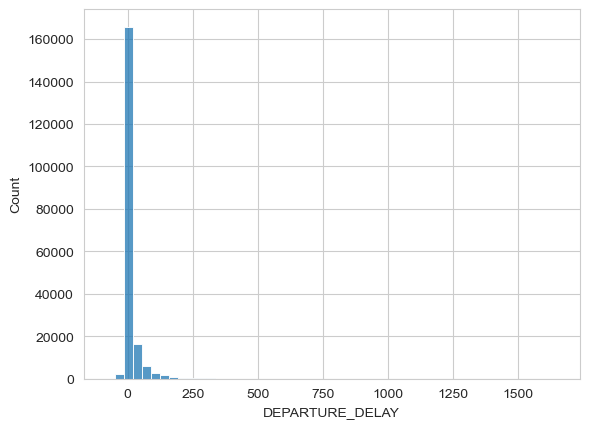

In [103]:
sns.histplot(df,x='DEPARTURE_DELAY', bins=50)


* viewing the graph from -80 to 200 for a better view

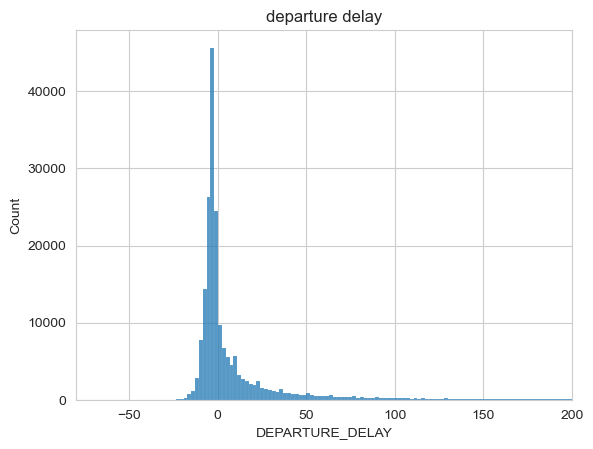

In [104]:
a=sns.histplot(df,x='DEPARTURE_DELAY', bins=800)
a.set_xlim(-80,200)
plt.title('departure delay')
plt.show()

* negative delay is departed before time
* positive is departed after time decided


In [105]:
df['ARRIVAL_DELAY'].describe()

count    196426.000000
mean          4.631210
std          40.090129
min         -80.000000
25%         -13.000000
50%          -5.000000
75%           8.000000
max        1636.000000
Name: ARRIVAL_DELAY, dtype: float64

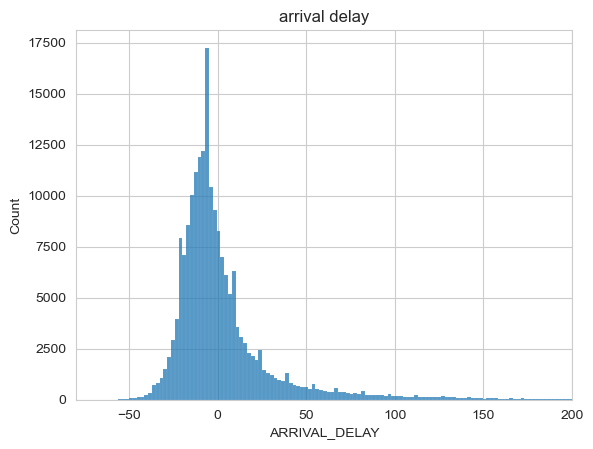

In [106]:
b=sns.histplot(df,x='ARRIVAL_DELAY',bins=800)
b.set_xlim(-80,200)
plt.title('arrival delay')
plt.show()

_right skewness shoes most flight tends to be before time_

In [107]:
df['AIRLINE'].describe()

count     200000
unique        14
top           WN
freq       43372
Name: AIRLINE, dtype: object

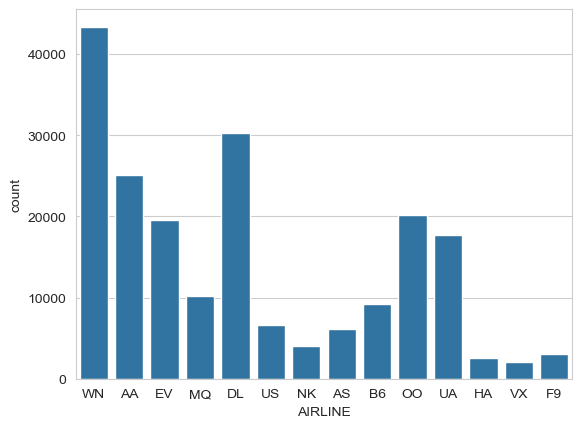

In [108]:
sns.set_style('whitegrid')
c=sns.countplot(df,x='AIRLINE')
plt.show()

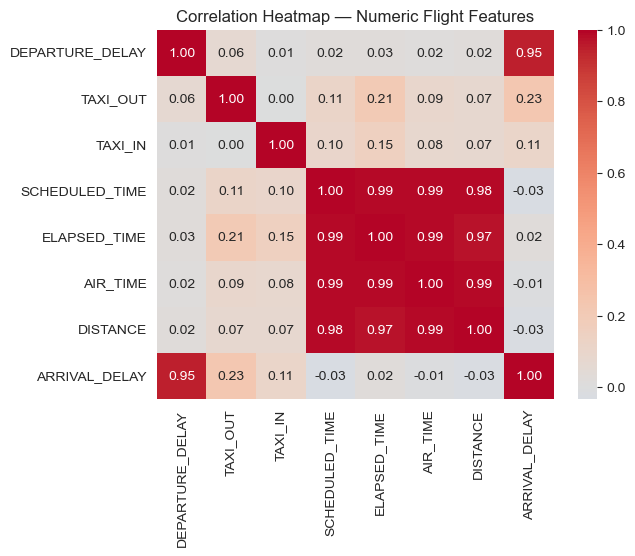

In [109]:
cols = ['DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN', 'SCHEDULED_TIME',
                'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'ARRIVAL_DELAY']
corr = df[cols].corr()


sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Flight Features')
plt.show()

- departure delay and arrival delay are highly correlated, i.e. late departure directly means late arrival
- air time and elapsed time are also hoghly related ,along with distance 

### checking if delay is some how related to how many flights are there on that day

#### checking if number of flights are some particular days

In [110]:
df['DAY_OF_WEEK'].describe()

count    200000.000000
mean          3.923585
std           1.976311
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max           7.000000
Name: DAY_OF_WEEK, dtype: float64

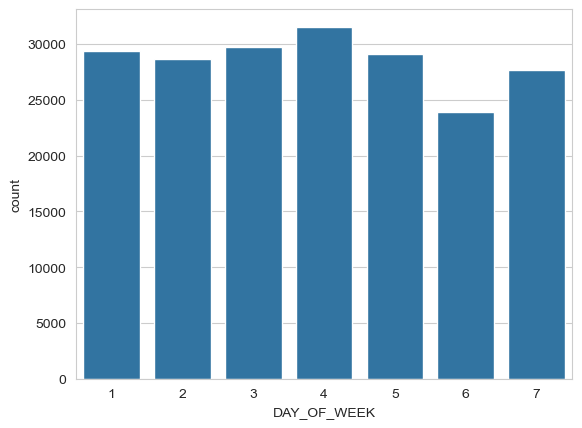

In [111]:
dayfl=sns.countplot(df, x='DAY_OF_WEEK')
plt.show()

- number of flight is similar on all days

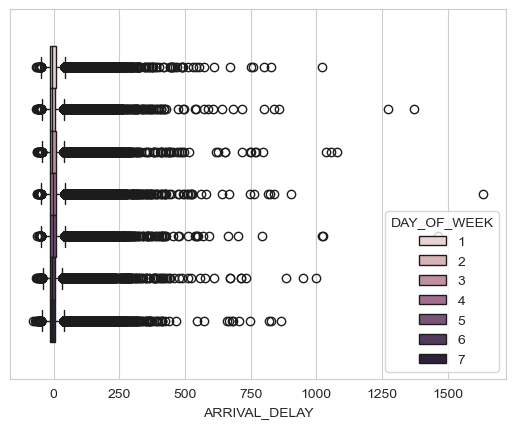

In [112]:
sns.boxplot(df, x='ARRIVAL_DELAY',hue='DAY_OF_WEEK')
plt.show()

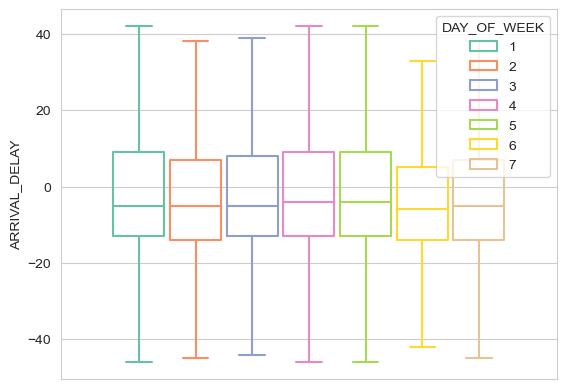

In [113]:
sns.boxplot(df, y='ARRIVAL_DELAY',hue='DAY_OF_WEEK',showfliers=False,palette='Set2',fill=False,gap=0.1)
plt.show()

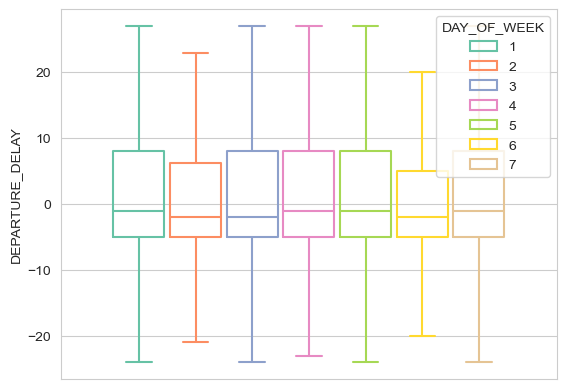

In [114]:
sns.boxplot(df, y='DEPARTURE_DELAY',hue='DAY_OF_WEEK',showfliers=False,palette='Set2',fill=False,gap=0.1)
plt.show()

- not much correlation in day and delay

### adding a columns to classify if a flight is late or not
- flight delay more than 15 minute is considered to be late

In [115]:

df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

print(df['IS_DELAYED'].value_counts())

IS_DELAYED
0    163010
1     36990
Name: count, dtype: int64


In [116]:
df['IS_DELAYED'].isnull().value_counts()

IS_DELAYED
False    200000
Name: count, dtype: int64

## PCA for dimentionality reduction of correlated features

In [123]:
num_cols = [
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'ELAPSED_TIME',
    'AIR_TIME',
    'DISTANCE',
    'TAXI_IN',
    ]
X_num = df[num_cols].fillna(df[num_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

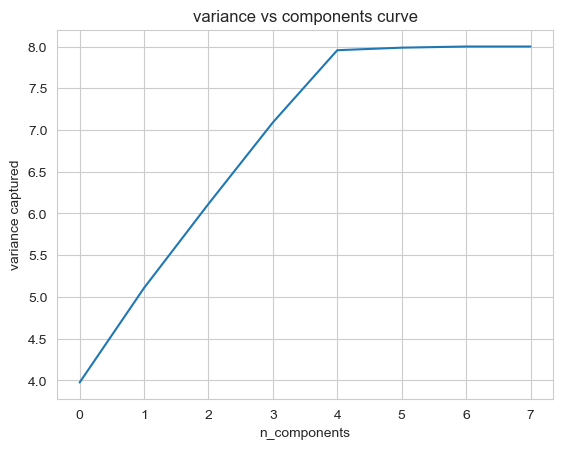

In [124]:
plt.plot(np.cumsum(pca.explained_variance_))
plt.xlabel('n_components')
plt.ylabel('variance captured')
plt.title('variance vs components curve')
plt.show()


- n=4 covers max variance

In [125]:
pca = PCA(n_components=4)
X_pca_scaled=pca.fit(X_pca)

In [126]:
pca.explained_variance_.shape

(4,)

In [127]:
pca.explained_variance_

array([3.97533131, 1.13225955, 1.00653661, 0.97614526])

In [128]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier



In [133]:
df_subset = df[num_cols + ['IS_DELAYED']].dropna()
X = df_subset[num_cols]
y = df_subset['IS_DELAYED']


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [135]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [136]:
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [137]:
models = {'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),}

In [142]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
results = []
for name, model in models.items():
  model.fit(X_train_pca, y_train)
  y_pred = model.predict(X_test_pca)
  results.append({
      'Model': name,
      'Accuracy': accuracy_score(y_test, y_pred),
      'Precision': precision_score(y_test, y_pred),
      'Recall': recall_score(y_test, y_pred),
      'F1-Score': f1_score(y_test, y_pred),
  })

In [143]:
results

[{'Model': 'Random Forest',
  'Accuracy': 0.8946189482258311,
  'Precision': 0.8127880184331797,
  'Recall': 0.5721816707218167,
  'F1-Score': 0.6715849595430747},
 {'Model': 'AdaBoost',
  'Accuracy': 0.8870080944865856,
  'Precision': 0.8098429319371728,
  'Recall': 0.5227088402270884,
  'F1-Score': 0.6353405076809332}]